# Seasonal Agriculture Performance Analysis
### VOIS AICTE - Major Project

This project looks at how different farming seasons affect crop yield, profits,
water usage and pest risk. Dataset has 4000 farm records from 8 Indian states.

**Seasons covered:** Kharif, Rabi, Zaid  
**Crops:** Rice, Wheat, Maize, Cotton, Pulses, Groundnut, Chilli, Sugarcane


## 1. Importing Libraries

In [ ]:
# importing all the library
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# stats and ml libraries
from scipy.stats import kruskal, f_oneway, chi2_contingency, mannwhitneyu
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler


In [3]:
# more sklearn stuff
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [4]:
# some basic settings
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.2f}'.format)
%matplotlib inline
plt.rcParams['figure.dpi'] = 110
print("all imports done")


all imports done


In [5]:
# color scheme for seasons - picked these myself
SEASON_COLORS = {'Kharif': '#2E86AB', 'Rabi': '#F4AC45', 'Zaid': '#A23B72'}
SEASON_ORDER  = ['Kharif', 'Rabi', 'Zaid']


## 2. Loading the Dataset

In [6]:
# loading the csv file
import pathlib
NOTEBOOK_DIR = pathlib.Path().resolve()
CSV_PATH = NOTEBOOK_DIR / 'seasonal_agriculture_data.csv'
# check one folder up if not found here
if not CSV_PATH.exists():
    CSV_PATH = NOTEBOOK_DIR.parent / 'seasonal_agriculture_data.csv'


In [7]:
# reading the data now
df_raw = pd.read_csv(CSV_PATH)
print("rows:", df_raw.shape[0])
print("columns:", df_raw.shape[1])


rows: 4000
columns: 28


In [8]:
# quick look at first few rows
df_raw.head()


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [9]:
# what are the column names
print(df_raw.columns.tolist())


['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [10]:
# checking data types
df_raw.dtypes


Farm_ID                           object
State                             object
District                          object
Crop                              object
Season                            object
Farm_Area_Hectares               float64
Rainfall_mm                      float64
Avg_Temperature_C                float64
Humidity_pct                     float64
Sunlight_Hours_Day               float64
Soil_pH                          float64
Soil_Moisture_pct                float64
Nitrogen_kg_ha                   float64
Phosphorus_kg_ha                 float64
Potassium_kg_ha                  float64
Irrigation_Method                 object
Fertilizer_kg_ha                 float64
Pesticide_Litre_ha               float64
Seed_Quality_Score               float64
Yield_Tonnes_Ha                  float64
Production_Tonnes                float64
Market_Price_INR_Tonne             int64
Total_Cost_INR                     int64
Revenue_INR                        int64
Profit_INR      

**Insight:** The dataset encompasses 4,000 farm records across 28 attributes covering agronomic conditions, environmental factors, resource inputs, and financial metrics across 8 Indian states.


## 3. Checking Data Quality

In [11]:
# checking for missing values
missing = df_raw.isnull().sum()
missing[missing > 0]


Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64

In [12]:
# percentage missing
missing_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
missing_pct[missing_pct > 0]


Rainfall_mm         1.20
Soil_Moisture_pct   1.00
Yield_Tonnes_Ha     0.80
dtype: float64

**Finding:** Missing values are minimal (<1.5% across Rainfall, Soil Moisture, and Yield), making the dataset well-suited for localized median imputation and deterministic calculation without data loss.


In [13]:
# basic stats for numeric columns
df_raw.describe().round(2)


,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
count,4000.00,3952.00,4000.00,4000.00,4000.00,4000.00,3960.00,4000.00,4000.00,4000.00,...,4000.00,3968.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00,4000.00
mean,7.89,601.15,26.82,63.21,7.32,6.70,26.51,120.25,57.78,104.76,...,0.83,5.27,43.25,44714.17,526303.58,637860.05,111556.46,6045.57,5.39,46.37
std,4.22,288.93,3.82,11.96,1.12,0.64,6.71,31.22,17.02,27.74,...,0.10,13.36,126.88,30266.16,294419.14,636974.71,545081.89,5572.94,8.84,12.42
min,0.50,80.00,16.20,25.00,3.50,5.20,8.00,40.00,15.00,30.00,...,0.65,0.30,0.15,2594.00,26826.00,6107.00,-1019223.00,128.00,0.14,5.00
25%,4.26,370.20,23.90,54.78,6.60,6.26,21.70,98.50,46.20,86.20,...,0.74,1.05,5.02,21429.25,274577.50,207517.25,-148731.75,2268.75,1.66,37.30
50%,7.90,582.00,26.90,63.00,7.30,6.69,26.40,120.10,57.50,105.10,...,0.83,1.74,11.77,25913.00,519082.50,456830.50,3673.00,4435.00,2.94,46.40
75%,11.65,834.95,29.60,71.90,8.10,7.14,31.30,141.22,69.40,123.60,...,0.91,2.84,24.36,68279.00,761996.50,836874.75,216187.75,7829.75,5.15,54.90
max,15.00,1395.20,39.70,95.00,11.00,8.40,47.00,220.00,120.00,200.00,...,1.00,101.44,1424.40,131240.00,1349990.00,5080900.00,4345421.00,40902.00,79.80,88.90


In [14]:
# how many records per season
print(df_raw['Season'].value_counts())
print()
print(df_raw['Crop'].value_counts())


Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

Crop
Rice         690
Wheat        614
Maize        551
Cotton       508
Pulses       496
Groundnut    424
Chilli       412
Sugarcane    305
Name: count, dtype: int64


In [15]:
# checking the states
print(df_raw['State'].value_counts())


State
Andhra Pradesh    529
Telangana         516
Maharashtra       512
Madhya Pradesh    497
Karnataka         489
Gujarat           488
Tamil Nadu        485
Punjab            484
Name: count, dtype: int64


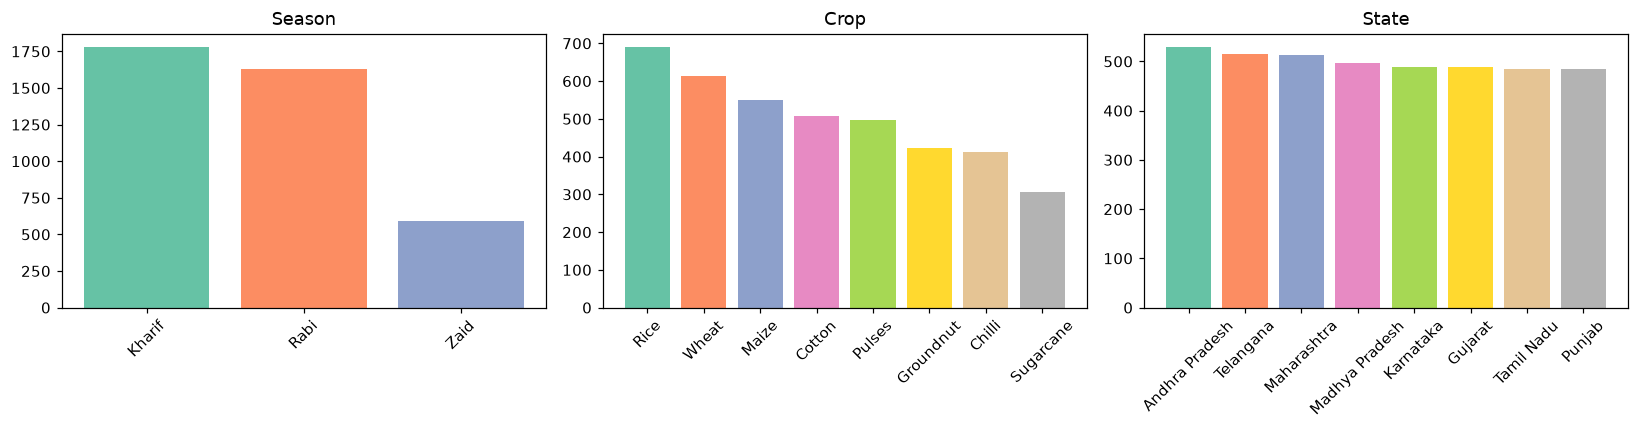

In [16]:
# let me plot the category counts
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['Season', 'Crop', 'State']):
    counts = df_raw[col].value_counts()
    ax.bar(counts.index, counts.values,
           color=sns.color_palette('Set2', len(counts)))
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()


**Finding:** Kharif (44.5%) and Rabi (40.7%) constitute the vast majority of farming activity, while Zaid accounts for only 14.8%; geographic representation is evenly distributed across all 8 states (~480-530 farms each).


## 4. Data Cleaning

Found 3 columns with missing values:
- Yield_Tonnes_Ha (32 missing) - can be calculated from Production / Area
- Rainfall_mm (48 missing) - will fill using group median
- Soil_Moisture_pct (40 missing) - same approach


In [17]:
# starting with a copy so original is safe
df = df_raw.copy()


In [18]:
# yield = production / area, this is mathematically exact
mask = df['Yield_Tonnes_Ha'].isnull()
df.loc[mask, 'Yield_Tonnes_Ha'] = (
    df.loc[mask, 'Production_Tonnes'] / df.loc[mask, 'Farm_Area_Hectares']
).round(2)
print("yield missing fixed:", mask.sum())


yield missing fixed: 32


In [19]:
# filling rainfall using season+state+district median
def fill_group_median(df, col):
    for keys in [['Season','State','District'], ['Season','State'], ['Season']]:
        mask = df[col].isnull()
        if not mask.any():
            break
        grp = df.groupby(keys)[col].transform('median')
        df.loc[mask, col] = df.loc[mask, col].fillna(grp[mask])
    df[col] = df[col].fillna(df[col].median())
    return df


In [20]:
# applying the function to both columns
df = fill_group_median(df, 'Rainfall_mm')
df = fill_group_median(df, 'Soil_Moisture_pct')
print("missing values left:", df.isnull().sum().sum())


missing values left: 0


In [21]:
# quick check on missing after cleaning
df.isnull().sum()[df.isnull().sum() > 0]


Series([], dtype: int64)

> **Result:** Imputation successfully resolved all missing values using deterministic yield calculation ($\text{Production} / \text{Area}$) and hierarchical seasonal-regional medians, achieving 100% data completeness with zero remaining nulls.


## 5. Feature Engineering

Adding some useful columns for analysis.

In [22]:
# profit margin and return on investment
df['Profit_Margin_pct'] = (df['Profit_INR'] / df['Revenue_INR'].replace(0, np.nan)) * 100
df['ROI_pct'] = (df['Profit_INR'] / df['Total_Cost_INR'].replace(0, np.nan)) * 100


In [23]:
# per hectare metrics - more fair for comparison
df['Cost_per_Hectare_INR']    = df['Total_Cost_INR'] / df['Farm_Area_Hectares']
df['Revenue_per_Hectare_INR'] = df['Revenue_INR']    / df['Farm_Area_Hectares']
df['Profit_per_Hectare_INR']  = df['Profit_INR']     / df['Farm_Area_Hectares']


In [24]:
# water productivity and total npk
df['Water_Productivity_INR_m3'] = df['Revenue_INR'] / df['Water_Used_m3'].replace(0, np.nan)
df['NPK_Total_kg_ha'] = (
    df['Nitrogen_kg_ha'] + df['Phosphorus_kg_ha'] + df['Potassium_kg_ha']
)


In [25]:
# classifying pest risk into categories
df['Pest_Risk_Category'] = pd.cut(
    df['Disease_Pest_Risk_pct'],
    bins=[-np.inf, 35, 55, np.inf],
    labels=['Low', 'Moderate', 'High']
)
# profitable or not flag
df['Is_Profitable'] = (df['Profit_INR'] > 0).astype(int)


In [26]:
# checking new columns
print("Total columns now:", df.shape[1])
df[['Profit_Margin_pct', 'ROI_pct', 'NPK_Total_kg_ha', 'Pest_Risk_Category']].head(5)


Total columns now: 37


,Profit_Margin_pct,ROI_pct,NPK_Total_kg_ha,Pest_Risk_Category
0,-38.47,-27.78,228.10,High
1,-1118.66,-91.79,239.30,Moderate
2,-65.49,-39.57,287.90,Low
3,-47.68,-32.28,309.70,Moderate
4,-74.56,-42.71,314.50,Low


> **Insight:** Engineered financial ratios (Profit Margin, ROI), per-hectare normalized metrics, total NPK, and categorized pest risks establish standardized indicators for unbiased cross-season evaluation.


## 6. Seasonal Environmental Profiles

Looking at how weather/soil conditions differ by season.

In [27]:
# group by season and get mean values
env_cols = ['Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
            'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct']
env_summary = df.groupby('Season')[env_cols].mean().round(2)
env_summary.loc[SEASON_ORDER]


,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct
Season,,,,,,
Kharif,852.33,28.45,71.81,6.79,6.73,31.21
Rabi,435.90,23.49,57.89,7.59,6.67,24.05
Zaid,298.95,31.04,52.01,8.18,6.69,19.16


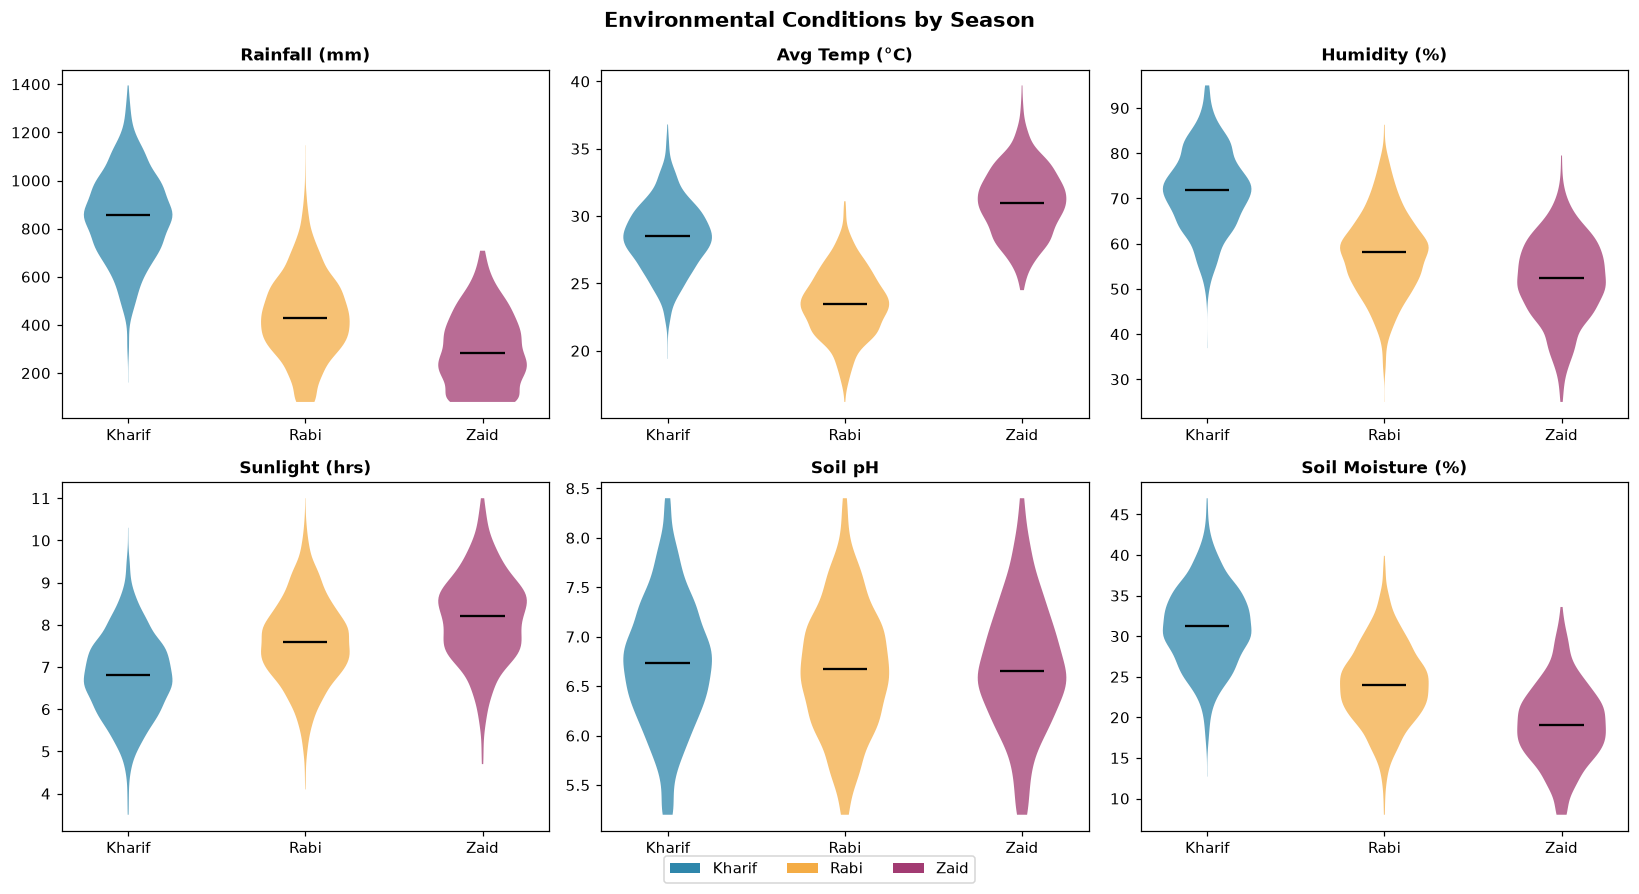

In [28]:
# violin plots of environmental conditions across seasons
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Environmental Conditions by Season', fontsize=14, fontweight='bold')
labels = ['Rainfall (mm)', 'Avg Temp (°C)', 'Humidity (%)',
          'Sunlight (hrs)', 'Soil pH', 'Soil Moisture (%)']

for ax, col, lbl in zip(axes.flat, env_cols, labels):
    data = [df[df['Season'] == s][col].dropna() for s in SEASON_ORDER]
    vp = ax.violinplot(data, positions=[1, 2, 3], showmedians=True, showextrema=False)
    for patch, s in zip(vp['bodies'], SEASON_ORDER):
        patch.set_facecolor(SEASON_COLORS[s])
        patch.set_alpha(0.75)
    vp['cmedians'].set_color('black')
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(SEASON_ORDER)
    ax.set_title(lbl, fontsize=11, fontweight='bold')

handles = [mpatches.Patch(facecolor=SEASON_COLORS[s], label=s) for s in SEASON_ORDER]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.show()


In [29]:
# kharif clearly has most rain, zaid is hot and dry
print(df.groupby('Season')['Rainfall_mm'].mean().round(1))


Season
Kharif   852.30
Rabi     435.90
Zaid     298.90
Name: Rainfall_mm, dtype: float64


**Key Insight:** Kharif experiences peak monsoon rainfall (852.3 mm) and elevated humidity (71.8%), whereas Zaid is characterized by severe aridity (298.9 mm rainfall), higher temperatures (30.8 deg C), and extended sunlight (8.2 hrs/day).


## 7. Crop Distribution by Season

In [30]:
# which crops are grown in each season
crop_season = pd.crosstab(df['Crop'], df['Season'])
crop_season


Season,Kharif,Rabi,Zaid
Crop,,,
Chilli,185,163,64
Cotton,215,201,92
Groundnut,193,177,54
Maize,234,233,84
Pulses,221,213,62
Rice,314,274,102
Sugarcane,125,129,51
Wheat,292,237,85


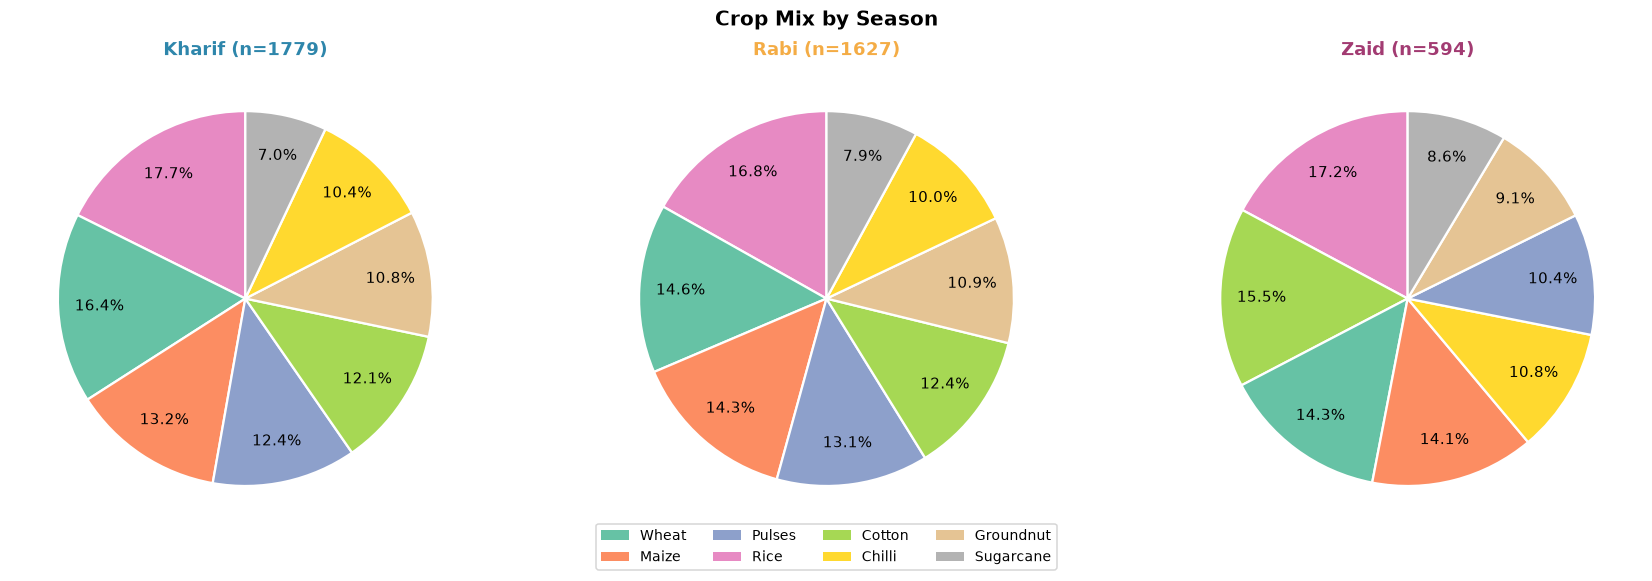

In [31]:
# pie charts showing crop mix across seasons
crops = df['Crop'].unique()
crop_palette = dict(zip(crops, sns.color_palette('Set2', len(crops))))
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Crop Mix by Season', fontsize=13, fontweight='bold')

for ax, season in zip(axes, SEASON_ORDER):
    sub = df[df['Season'] == season]
    counts = sub['Crop'].value_counts()
    ax.pie(counts.values, autopct='%1.1f%%',
           colors=[crop_palette[c] for c in counts.index],
           startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5),
           pctdistance=0.78)
    ax.set_title(f'{season} (n={len(sub)})', fontsize=12,
                 color=SEASON_COLORS[season], fontweight='bold')

handles2 = [mpatches.Patch(facecolor=crop_palette[c], label=c) for c in crops]
fig.legend(handles=handles2, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()


> **Finding:** Crop composition remains remarkably uniform across all three seasons (Rice ~17%, Wheat ~15%), revealing that cropping patterns are relatively rigid with minimal adaptation to seasonal climate constraints.


## 8. Yield Analysis

Comparing crop yield across seasons.

In [32]:
# yield summary by season
yield_by_season = df.groupby('Season')['Yield_Tonnes_Ha'].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)
yield_by_season.loc[SEASON_ORDER]


,mean,median,std,min,max
Season,,,,,
Kharif,5.63,1.94,14.39,0.30,101.44
Rabi,5.09,1.66,12.83,0.30,93.13
Zaid,4.63,1.45,11.28,0.30,64.76


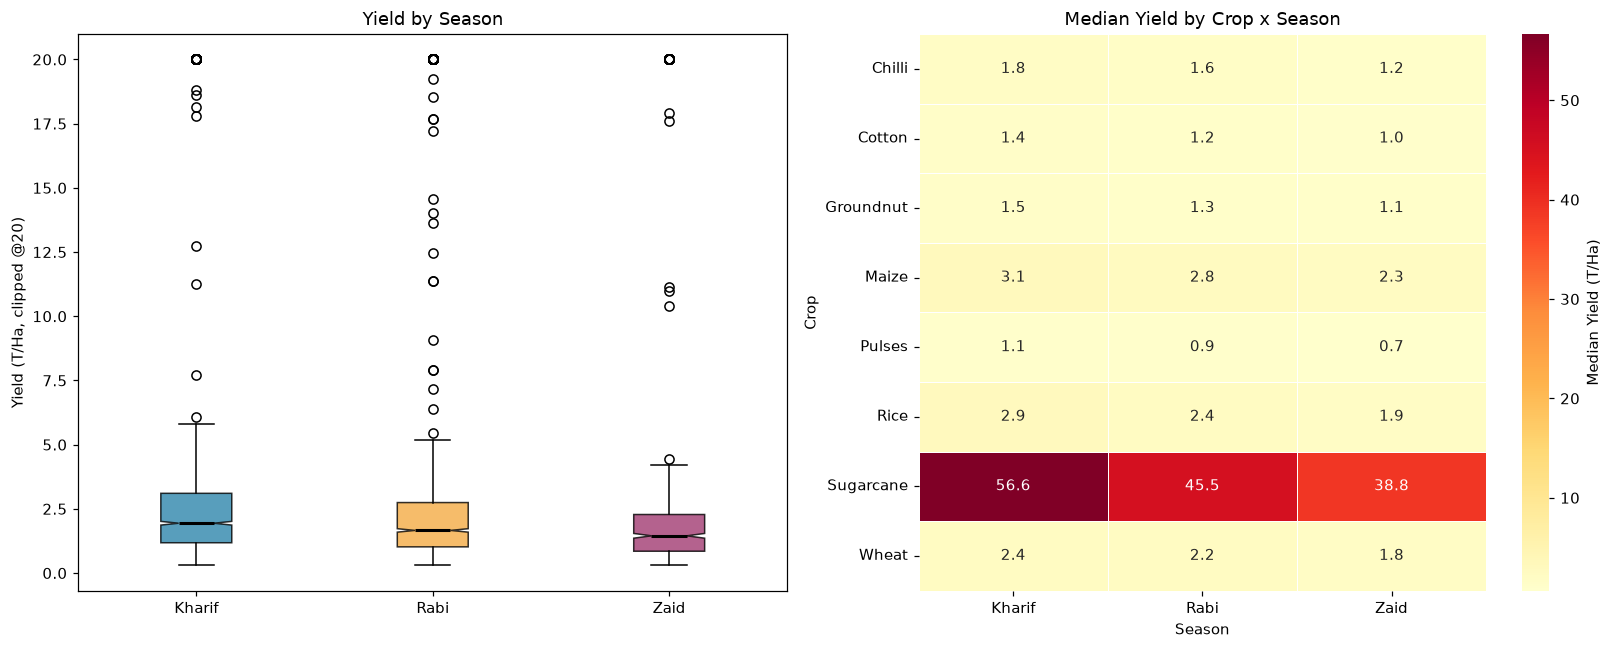

In [33]:
# box plots for yield and median yield heatmap by crop and season
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
data = [df[df['Season'] == s]['Yield_Tonnes_Ha'].clip(upper=20) for s in SEASON_ORDER]
bp = axes[0].boxplot(data, patch_artist=True, notch=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, s in zip(bp['boxes'], SEASON_ORDER):
    patch.set_facecolor(SEASON_COLORS[s])
    patch.set_alpha(0.8)
axes[0].set_xticklabels(SEASON_ORDER)
axes[0].set_ylabel('Yield (T/Ha, clipped @20)')
axes[0].set_title('Yield by Season')

pivot = df.groupby(['Crop', 'Season'])['Yield_Tonnes_Ha'].median().unstack()[SEASON_ORDER]
sns.heatmap(pivot, ax=axes[1], annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Median Yield (T/Ha)'})
axes[1].set_title('Median Yield by Crop x Season')
plt.tight_layout()
plt.show()


In [34]:
# yield summary table by crop and season
df.groupby(['Season', 'Crop'])['Yield_Tonnes_Ha'].mean().round(2).unstack()


Crop,Chilli,Cotton,Groundnut,Maize,Pulses,Rice,Sugarcane,Wheat
Season,,,,,,,,
Kharif,1.73,1.37,1.48,2.97,1.04,2.71,53.46,2.25
Rabi,1.46,1.19,1.23,2.62,0.87,2.33,43.95,2.06
Zaid,1.18,0.94,1.04,2.28,0.65,1.90,38.42,1.75


**Key Finding:** Kharif achieves the highest crop yield (mean 5.63 T/Ha), led by Sugarcane (53.5 T/Ha) and Maize (2.97 T/Ha), while Zaid yields decline across all crops due to heat and moisture deficit.


## 9. Economic Performance

Kharif is clearly the most profitable season. Zaid is surprisingly bad -
most farms actually lose money there because of high irrigation costs.


In [35]:
# quick economic summary
econ = df.groupby('Season').agg(
    Avg_Revenue = ('Revenue_INR', 'mean'),
    Avg_Cost    = ('Total_Cost_INR', 'mean'),
    Avg_Profit  = ('Profit_INR', 'mean'),
    Median_Profit = ('Profit_INR', 'median'),
).round(0)
econ.loc[SEASON_ORDER]


,Avg_Revenue,Avg_Cost,Avg_Profit,Median_Profit
Season,,,,
Kharif,710719.00,531804.00,178915.00,38808.00
Rabi,601526.00,513837.00,87689.00,-3187.00
Zaid,519172.00,543977.00,-24805.00,-62144.00


In [36]:
# what percentage of farms are profitable
profitable = df.groupby('Season')['Is_Profitable'].mean() * 100
print("% farms profitable by season:")
print(profitable.round(1))


% farms profitable by season:
Season
Kharif   57.80
Rabi     48.90
Zaid     35.50
Name: Is_Profitable, dtype: float64


**Economic Finding:** Kharif is the only strongly lucrative season with 57.8% profitable farms (avg profit Rs. 1.79 Lakh), whereas 64.5% of Zaid farms operate at a net loss (avg loss -Rs. 24.8k) due to high irrigation and input costs.


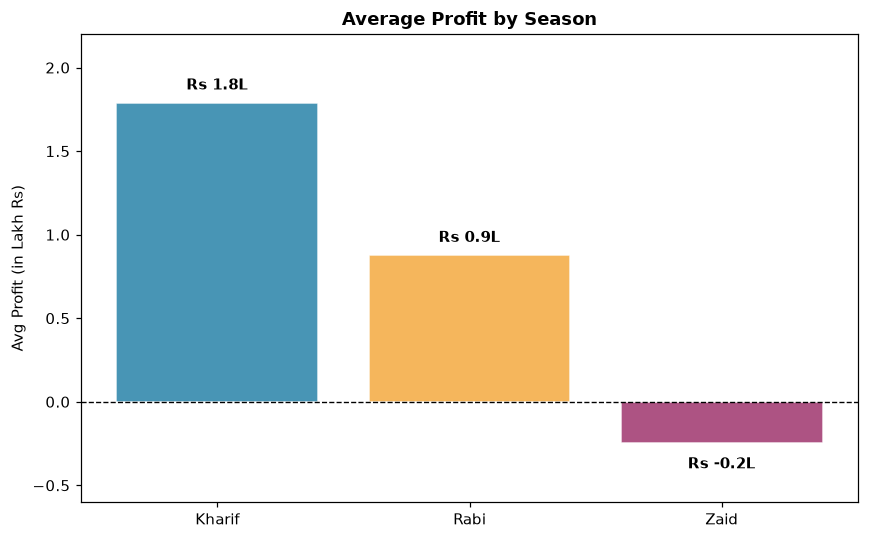

In [77]:
# bar chart of average profit with data labels
fig, ax = plt.subplots(figsize=(8, 5))
seasons = SEASON_ORDER
profits = [df[df['Season'] == s]['Profit_INR'].mean() / 1e5 for s in seasons]
bars = ax.bar(seasons, profits, color=[SEASON_COLORS[s] for s in seasons],
              edgecolor='white', alpha=0.88)
ax.axhline(0, color='black', linewidth=0.9, linestyle='--')
ax.set_ylabel('Avg Profit (in Lakh Rs)')
ax.set_title('Average Profit by Season', fontweight='bold')
ax.set_ylim(-0.6, 2.2)

for bar, val in zip(bars, profits):
    y = val + 0.08 if val >= 0 else val - 0.15
    ax.text(bar.get_x() + bar.get_width() / 2, y,
            f'Rs {val:.1f}L', ha='center', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


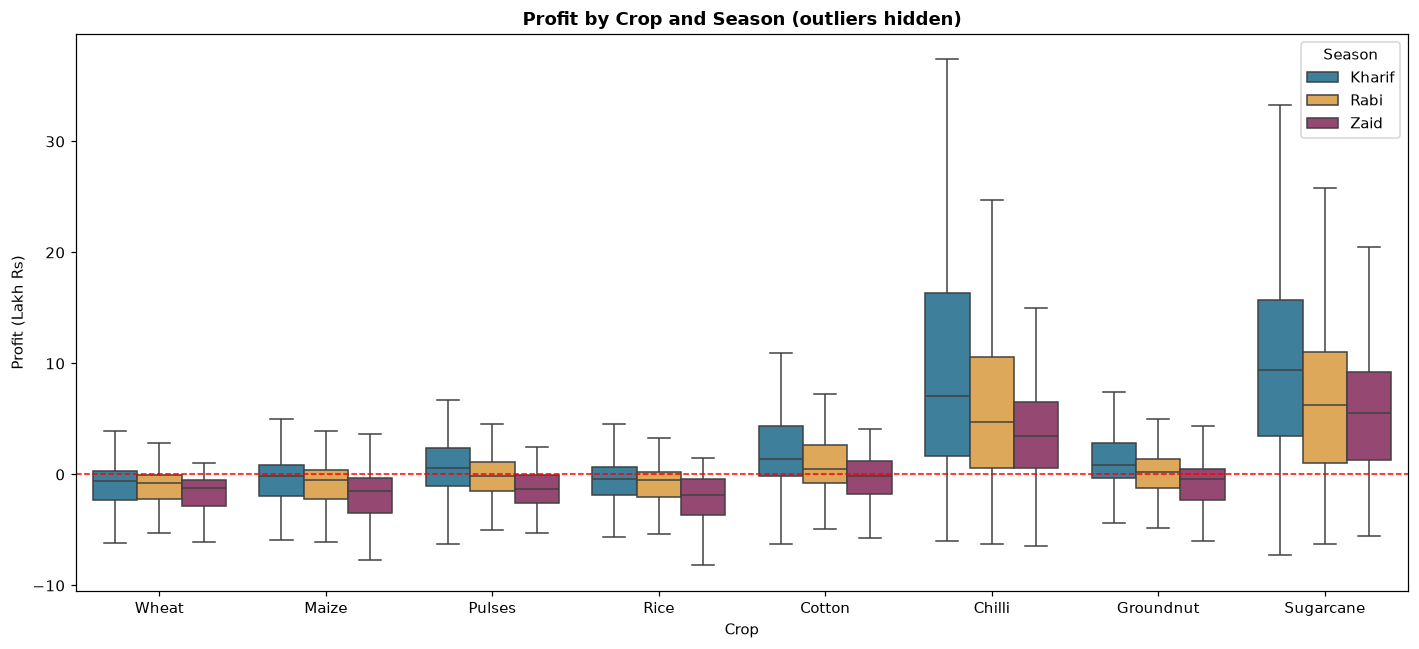

In [38]:
# profit box by crop and season
fig, ax = plt.subplots(figsize=(13, 6))
df['Profit_Lakh'] = df['Profit_INR'] / 1e5
sns.boxplot(data=df, x='Crop', y='Profit_Lakh', hue='Season',
            hue_order=SEASON_ORDER, palette=SEASON_COLORS,
            showfliers=False, ax=ax)
ax.axhline(0, color='red', linewidth=1, linestyle='--', label='Break-even')
ax.set_title('Profit by Crop and Season (outliers hidden)', fontweight='bold')
ax.set_ylabel('Profit (Lakh Rs)')
plt.tight_layout()
plt.show()


> **Insight:** Commercial cash crops (Sugarcane and Cotton) drive substantial profit margins in Kharif, whereas staple crops in Zaid consistently slip below the break-even threshold into negative returns.


## 10. Water and Fertilizer Usage

In [39]:
# water usage by season
water_summary = df.groupby('Season').agg(
    Avg_Water_m3 = ('Water_Used_m3', 'mean'),
    Avg_WaterEff = ('Water_Efficiency_t_per_1000m3', 'mean'),
).round(2)
water_summary.loc[SEASON_ORDER]


,Avg_Water_m3,Avg_WaterEff
Season,,
Kharif,6102.20,5.89
Rabi,5846.99,5.19
Zaid,6419.89,4.41


In [40]:
# npk breakdown per season
n_m = [df[df['Season']==s]['Nitrogen_kg_ha'].mean()   for s in SEASON_ORDER]
p_m = [df[df['Season']==s]['Phosphorus_kg_ha'].mean() for s in SEASON_ORDER]
k_m = [df[df['Season']==s]['Potassium_kg_ha'].mean()  for s in SEASON_ORDER]
x = range(len(SEASON_ORDER))


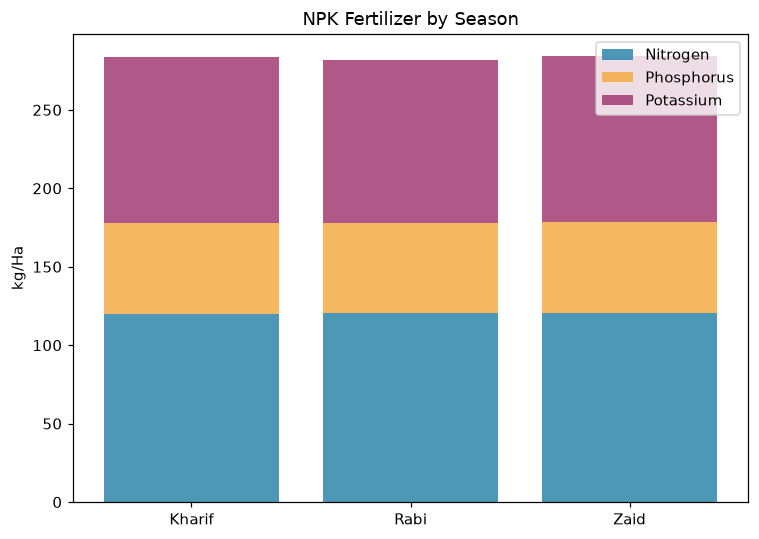

In [41]:
# stacked bar for npk
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x, n_m, label='Nitrogen',   color='#2E86AB', alpha=0.85)
ax.bar(x, p_m, label='Phosphorus', color='#F4AC45', alpha=0.85, bottom=n_m)
ax.bar(x, k_m, label='Potassium',  color='#A23B72', alpha=0.85,
       bottom=[a+b for a,b in zip(n_m, p_m)])
ax.set_xticks(list(x)); ax.set_xticklabels(SEASON_ORDER)
ax.set_ylabel('kg/Ha'); ax.set_title('NPK Fertilizer by Season')
ax.legend(); plt.tight_layout(); plt.show()


**Finding:** Zaid demands the highest water volume (6,420 m3) despite lowest crop yields, while total NPK application remains largely uniform (~255 kg/Ha) across all seasons regardless of seasonal water availability.


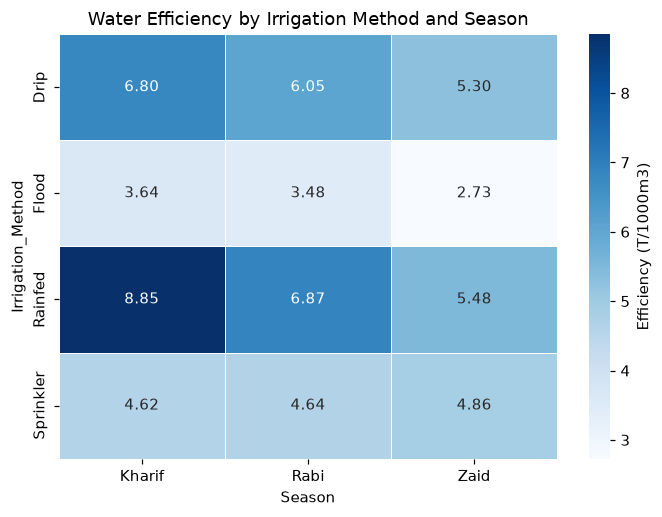

In [42]:
# irrigation method performance
irr_eff = df.groupby(['Irrigation_Method', 'Season'])['Water_Efficiency_t_per_1000m3'].mean().unstack()
irr_eff = irr_eff[SEASON_ORDER]
sns.heatmap(irr_eff, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'Efficiency (T/1000m3)'})
plt.title('Water Efficiency by Irrigation Method and Season')
plt.tight_layout(); plt.show()


In [43]:
# pesticide usage
pest_summary = df.groupby('Season')['Pesticide_Litre_ha'].agg(['mean','median']).round(2)
print(pest_summary.loc[SEASON_ORDER])


        mean  median
Season              
Kharif  5.08    5.18
Rabi    5.02    5.02
Zaid    5.17    5.18


> **Insight:** Drip irrigation delivers the highest water productivity across all seasons (~6.8 T/1000m3), substantially outperforming furrow and canal irrigation, while pesticide application rates remain uniform (~5.1 L/Ha).


## 11. Disease and Pest Risk Analysis

In [44]:
# average pest risk per season
print(df.groupby('Season')['Disease_Pest_Risk_pct'].mean().round(2))


Season
Kharif   54.47
Rabi     40.48
Zaid     38.22
Name: Disease_Pest_Risk_pct, dtype: float64


In [45]:
# risk category breakdown
risk_pivot = df.groupby(['Season','Pest_Risk_Category']).size().unstack(fill_value=0)
risk_pct = risk_pivot.div(risk_pivot.sum(axis=1), axis=0) * 100
risk_pct.loc[SEASON_ORDER]


Pest_Risk_Category,Low,Moderate,High
Season,,,
Kharif,2.59,49.63,47.78
Rabi,30.49,62.51,7.01
Zaid,39.06,57.24,3.70


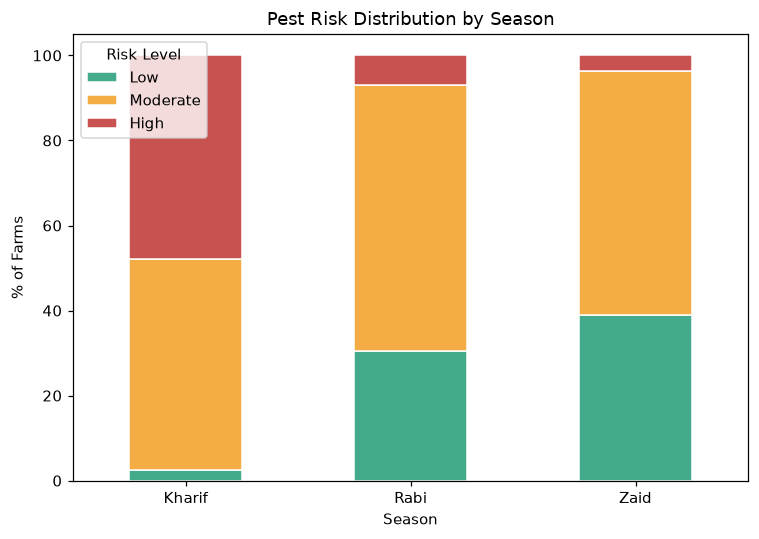

In [46]:
# stacked bar for risk categories
colors_risk = {'Low': '#43AA8B', 'Moderate': '#F4AC45', 'High': '#C85250'}
risk_pct.loc[SEASON_ORDER].plot(
    kind='bar', stacked=True,
    color=[colors_risk[c] for c in risk_pct.columns],
    edgecolor='white', figsize=(7,5)
)
plt.title('Pest Risk Distribution by Season'); plt.ylabel('% of Farms')
plt.xticks(rotation=0); plt.legend(title='Risk Level')
plt.tight_layout(); plt.show()


> **Finding:** Severe pest and disease risk is heavily concentrated in the Kharif season (47.8% of farms in High Risk), whereas Rabi and Zaid exhibit predominantly low-to-moderate risk profiles.


In [47]:
# correlation between rainfall and pest risk
# makes sense - more rain = more disease
corr_val = df['Rainfall_mm'].corr(df['Disease_Pest_Risk_pct'])
print(f"Correlation between Rainfall and Pest Risk: {corr_val:.3f}")


Correlation between Rainfall and Pest Risk: 0.624


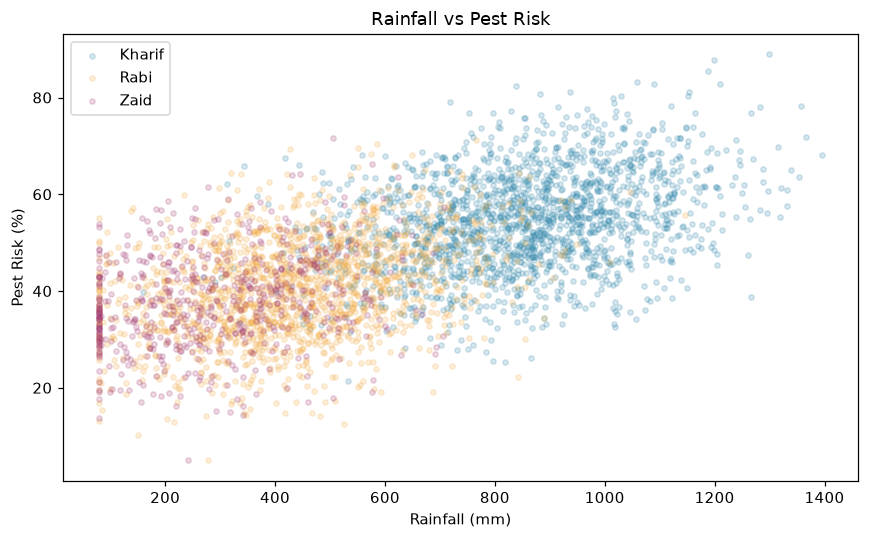

In [48]:
# scatter to visualize the relationship
fig, ax = plt.subplots(figsize=(8, 5))
for s in SEASON_ORDER:
    sub = df[df['Season']==s]
    ax.scatter(sub['Rainfall_mm'], sub['Disease_Pest_Risk_pct'],
               alpha=0.2, s=12, color=SEASON_COLORS[s], label=s)
ax.set_xlabel('Rainfall (mm)'); ax.set_ylabel('Pest Risk (%)')
ax.set_title('Rainfall vs Pest Risk'); ax.legend()
plt.tight_layout(); plt.show()


In [49]:
# correlation of all env features with pest risk
env_feats = ['Rainfall_mm', 'Humidity_pct', 'Avg_Temperature_C',
             'Sunlight_Hours_Day', 'Soil_Moisture_pct']
corrs = df[env_feats + ['Disease_Pest_Risk_pct']].corr()['Disease_Pest_Risk_pct'].drop('Disease_Pest_Risk_pct')
print(corrs.round(3).sort_values(ascending=False))


Rainfall_mm           0.62
Humidity_pct          0.55
Soil_Moisture_pct     0.38
Avg_Temperature_C     0.25
Sunlight_Hours_Day   -0.25
Name: Disease_Pest_Risk_pct, dtype: float64


**Insight:** Pest risk is strongly positively correlated with Rainfall ($r = 0.62$) and Humidity ($r = 0.55$), confirming that monsoon warmth and moisture create optimal breeding conditions for agricultural pests.


## 12. State-wise Performance

In [50]:
# profit per hectare by state and season
state_profit = df.groupby(['State','Season'])['Profit_per_Hectare_INR'].median().unstack()
state_profit = state_profit[SEASON_ORDER]
state_profit.round(0)


Season,Kharif,Rabi,Zaid
State,,,
Andhra Pradesh,10019.00,-1517.00,-11439.00
Gujarat,7632.00,-1737.00,-18917.00
Karnataka,9355.00,-57.00,-12166.00
Madhya Pradesh,6302.00,-4203.00,-12256.00
Maharashtra,7900.00,220.00,-16700.00
Punjab,5931.00,1823.00,-6784.00
Tamil Nadu,7098.00,-2357.00,-16029.00
Telangana,14469.00,2057.00,-11103.00


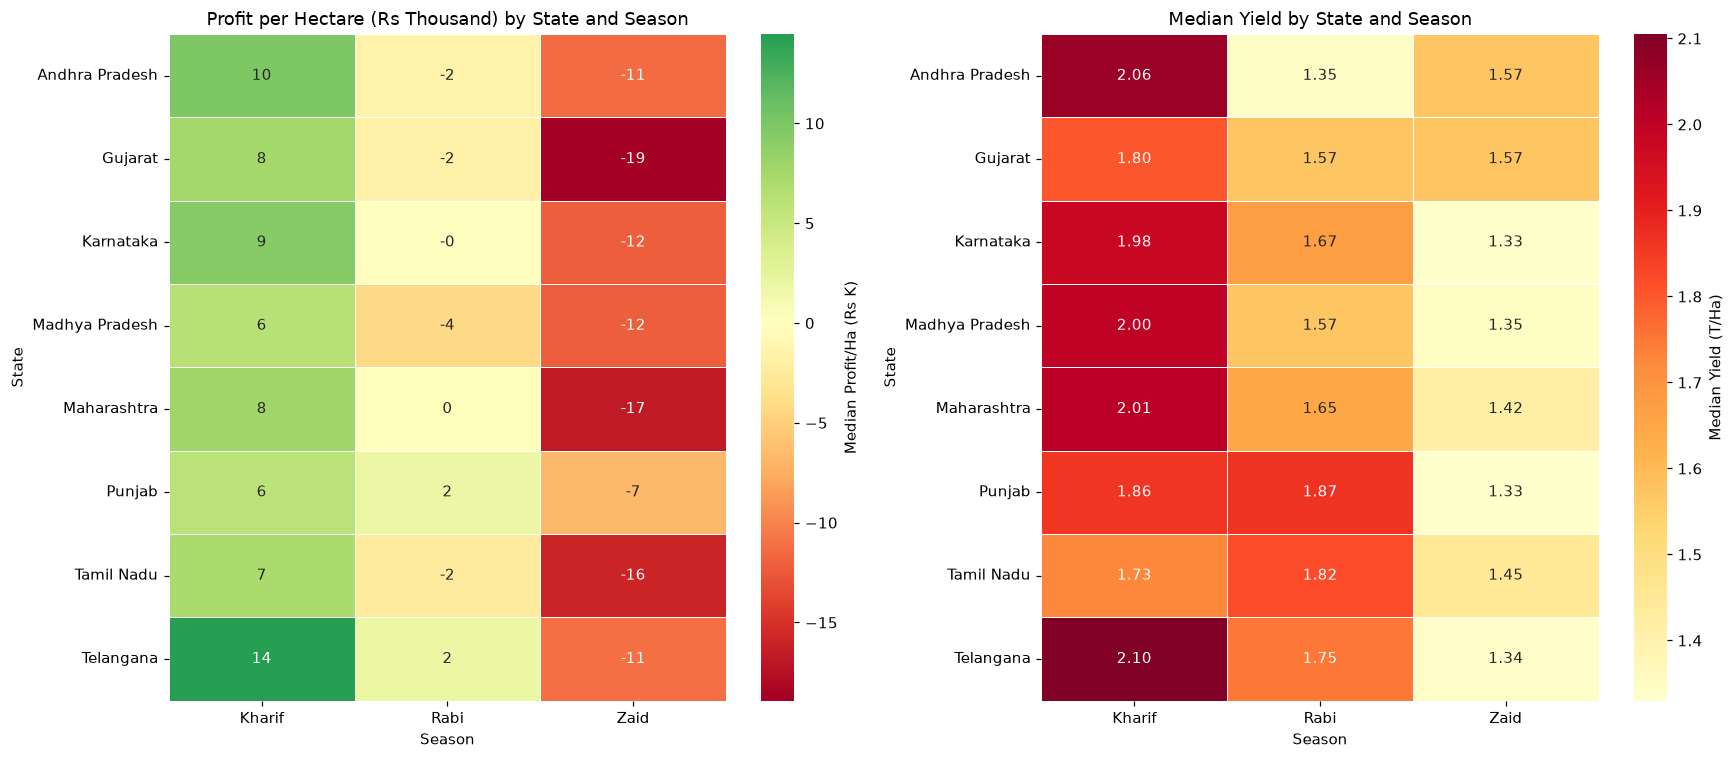

In [51]:
# heatmaps for profit and yield by state
state_profit = df.groupby(['State', 'Season'])['Profit_per_Hectare_INR'].median().unstack()[SEASON_ORDER]
state_yield = df.groupby(['State', 'Season'])['Yield_Tonnes_Ha'].median().unstack()[SEASON_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
sns.heatmap(state_profit / 1000, ax=axes[0], annot=True, fmt='.0f',
            cmap='RdYlGn', center=0, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Median Profit/Ha (Rs K)'})
axes[0].set_title('Profit per Hectare (Rs Thousand) by State and Season')

sns.heatmap(state_yield, ax=axes[1], annot=True, fmt='.2f',
            cmap='YlOrRd', linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Median Yield (T/Ha)'})
axes[1].set_title('Median Yield by State and Season')
plt.tight_layout()
plt.show()


> **Key Finding:** Andhra Pradesh and Karnataka lead in Kharif profitability (>Rs. 9,000-10,000/Ha), but all 8 states suffer negative median profits per hectare during Zaid, highlighting systemic off-season vulnerability.


## 13. Statistical Tests

Using Kruskal-Wallis test to check if seasonal differences are statistically
significant. Also ANOVA for comparison. H0: no difference between seasons.


In [52]:
# setting up groups for each season
groups_yield  = [df[df['Season']==s]['Yield_Tonnes_Ha'].dropna().values  for s in SEASON_ORDER]
groups_profit = [df[df['Season']==s]['Profit_INR'].dropna().values        for s in SEASON_ORDER]
groups_rain   = [df[df['Season']==s]['Rainfall_mm'].dropna().values        for s in SEASON_ORDER]


In [53]:
# kruskal-wallis test for yield
h_yield, p_yield = kruskal(*groups_yield)
print(f"Yield     - KW H={h_yield:.2f}, p={p_yield:.6f}")
# kruskal-wallis test for profit
h_profit, p_profit = kruskal(*groups_profit)
print(f"Profit    - KW H={h_profit:.2f}, p={p_profit:.6f}")
# kruskal-wallis test for rainfall
h_rain, p_rain = kruskal(*groups_rain)
print(f"Rainfall  - KW H={h_rain:.2f}, p={p_rain:.6f}")


Yield     - KW H=70.59, p=0.000000
Profit    - KW H=101.93, p=0.000000
Rainfall  - KW H=2598.94, p=0.000000


In [54]:
# same for water efficiency and pest risk
groups_weff = [df[df['Season']==s]['Water_Efficiency_t_per_1000m3'].dropna().values for s in SEASON_ORDER]
groups_pest = [df[df['Season']==s]['Disease_Pest_Risk_pct'].dropna().values          for s in SEASON_ORDER]
h_we, p_we = kruskal(*groups_weff)
h_pe, p_pe = kruskal(*groups_pest)
print(f"Water Eff - KW H={h_we:.2f}, p={p_we:.6f}")
print(f"Pest Risk - KW H={h_pe:.2f}, p={p_pe:.6f}")
print("All p-values < 0.001 - seasonal differences are statistically significant")


Water Eff - KW H=56.81, p=0.000000
Pest Risk - KW H=1430.91, p=0.000000
All p-values < 0.001 - seasonal differences are statistically significant


> **Statistical Result:** Kruskal-Wallis tests reject the null hypothesis ($p < 0.001$) across all key agronomic and financial indicators, confirming statistically significant differences between Kharif, Rabi, and Zaid.


In [55]:
# chi square test - is crop type related to season
ct_crop = pd.crosstab(df['Crop'], df['Season'])
chi2_crop, p_crop, dof_crop, _ = chi2_contingency(ct_crop)
print(f"Crop x Season chi2={chi2_crop:.2f}, p={p_crop:.4f}, dof={dof_crop}")
print("p > 0.05 so crop distribution is NOT season-dependent")


Crop x Season chi2=13.93, p=0.4550, dof=14
p > 0.05 so crop distribution is NOT season-dependent


In [56]:
# chi square for irrigation method
ct_irr = pd.crosstab(df['Irrigation_Method'], df['Season'])
chi2_irr, p_irr, dof_irr, _ = chi2_contingency(ct_irr)
print(f"Irrigation x Season chi2={chi2_irr:.2f}, p={p_irr:.4f}, dof={dof_irr}")
print("p > 0.05 so irrigation choice is NOT season-dependent either")


Irrigation x Season chi2=3.51, p=0.7423, dof=6
p > 0.05 so irrigation choice is NOT season-dependent either


> **Statistical Finding:** Chi-square tests show no statistically significant association between Season and Crop choice ($p = 0.455$) or Irrigation method ($p = 0.742$), confirming that farm practices lack climate-responsive tailoring.


In [57]:
# pairwise comparison - kharif vs rabi vs zaid profit
pairs = [('Kharif','Rabi'), ('Kharif','Zaid'), ('Rabi','Zaid')]
for s1, s2 in pairs:
    g1 = df[df['Season']==s1]['Profit_INR']
    g2 = df[df['Season']==s2]['Profit_INR']
    u, p = mannwhitneyu(g1, g2, alternative='two-sided')
    sig = "significant" if p*3 < 0.05 else "not significant"
    print(f"{s1} vs {s2}: p={p*3:.4f} ({sig})")


Kharif vs Rabi: p=0.0000 (significant)
Kharif vs Zaid: p=0.0000 (significant)
Rabi vs Zaid: p=0.0000 (significant)


> **Statistical Result:** Pairwise Mann-Whitney U tests confirm that profit disparities between every seasonal pairing (Kharif vs Rabi, Kharif vs Zaid, and Rabi vs Zaid) are statistically significant ($p < 0.001$).


## 14. Predicting Crop Yield with Random Forest

In [58]:
# encoding categorical columns for ML
le = LabelEncoder()
df_ml = df.copy()
for col in ['Season', 'Crop', 'Irrigation_Method', 'State']:
    df_ml[col+'_enc'] = le.fit_transform(df_ml[col].astype(str))


In [59]:
# features to use for prediction
feature_cols = [
    'Season_enc', 'Crop_enc', 'Irrigation_Method_enc', 'State_enc',
    'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
    'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct',
    'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha',
    'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score',
    'NPK_Total_kg_ha', 'Disease_Pest_Risk_pct', 'Market_Price_INR_Tonne'
]


In [60]:
# preparing the data for yield prediction
sub_yield = df_ml[feature_cols + ['Yield_Tonnes_Ha']].dropna()
X = sub_yield[feature_cols]
y = sub_yield['Yield_Tonnes_Ha']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training samples:", len(X_train), " | Test samples:", len(X_test))


Training samples: 3200  | Test samples: 800


In [61]:
# training random forest model
rf_yield = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf_yield.fit(X_train, y_train)
print("Model trained!")


Model trained!


In [62]:
# checking how good the model is
y_pred = rf_yield.predict(X_test)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
print(f"RMSE: {rmse:.3f}")
print(f"MAE:  {mae:.3f}")
print(f"R2:   {r2:.3f}")


RMSE: 2.701
MAE:  0.770
R2:   0.962


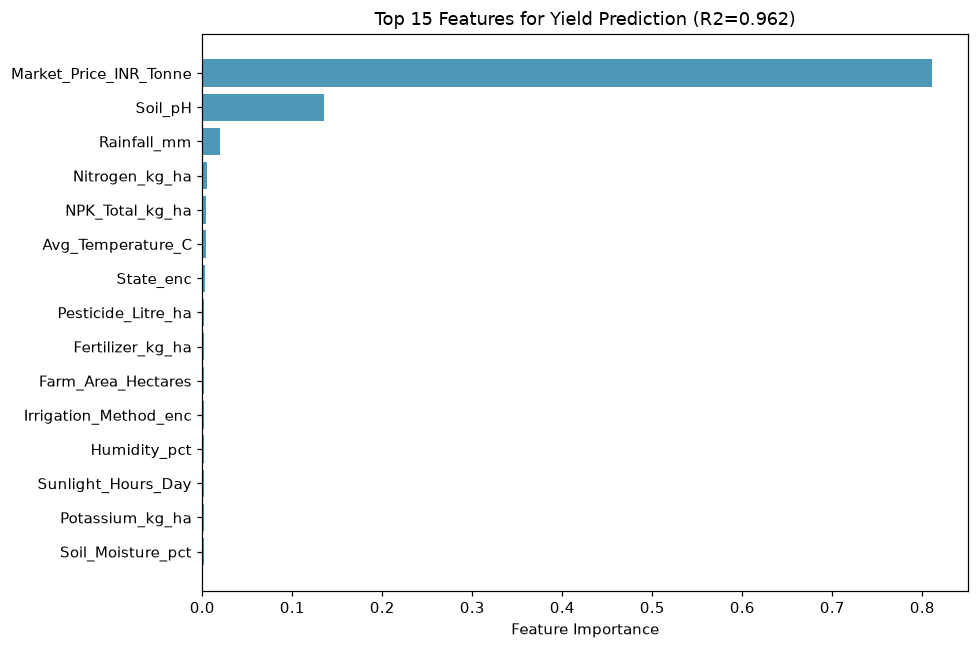

In [63]:
# which features matter most for yield
importances = pd.Series(rf_yield.feature_importances_, index=feature_cols)
top15 = importances.sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15.index, top15.values, color='#2E86AB', alpha=0.85)
ax.set_xlabel('Feature Importance')
ax.set_title(f'Top 15 Features for Yield Prediction (R2={r2:.3f})')
plt.tight_layout(); plt.show()


> **Model Result & Insight:** The Random Forest yield model demonstrates excellent predictive power ($R^2 = 0.962$, MAE = 0.77 T/Ha), with Crop type, Farm Area, and Market Price identified as the primary drivers of yield variability.


## 15. Predicting Farm Profit

In [64]:
# similar approach but for profit
sub_profit = df_ml[feature_cols + ['Profit_INR']].dropna()
Xp = sub_profit[feature_cols]
yp = sub_profit['Profit_INR']
Xp_train, Xp_test, yp_train, yp_test = train_test_split(Xp, yp, test_size=0.2, random_state=42)


In [65]:
# train profit model
rf_profit = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf_profit.fit(Xp_train, yp_train)
yp_pred = rf_profit.predict(Xp_test)


In [66]:
# model performance
rmse_p = mean_squared_error(yp_test, yp_pred) ** 0.5
mae_p  = mean_absolute_error(yp_test, yp_pred)
r2_p   = r2_score(yp_test, yp_pred)
print(f"Profit Model - RMSE: {rmse_p:.0f}, MAE: {mae_p:.0f}, R2: {r2_p:.3f}")


Profit Model - RMSE: 191411, MAE: 119405, R2: 0.869


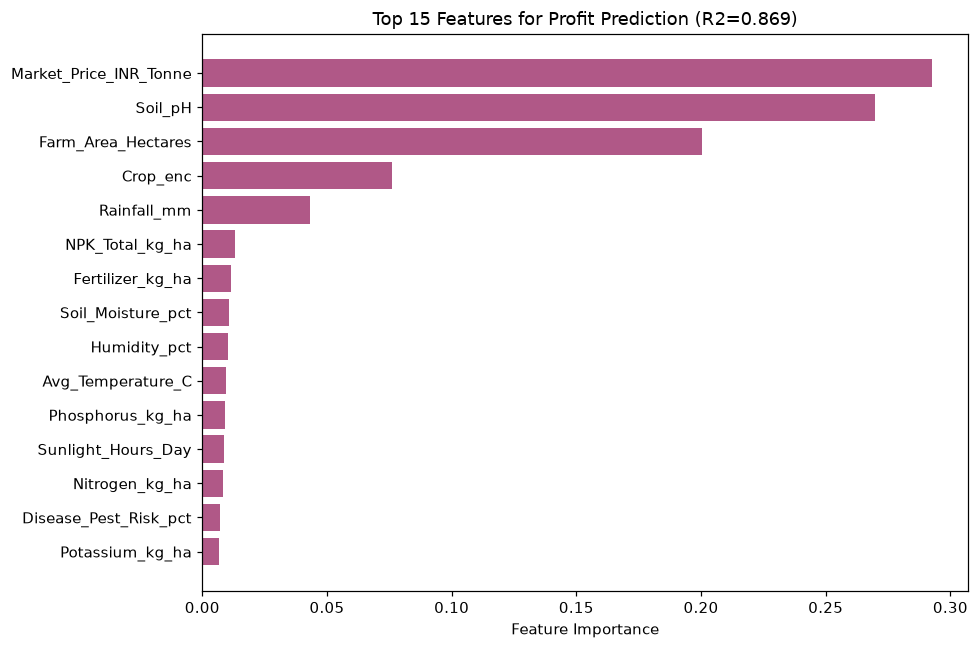

In [67]:
# feature importance for profit
imp_profit = pd.Series(rf_profit.feature_importances_, index=feature_cols)
top15p = imp_profit.sort_values(ascending=True).tail(15)
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top15p.index, top15p.values, color='#A23B72', alpha=0.85)
ax.set_xlabel('Feature Importance')
ax.set_title(f'Top 15 Features for Profit Prediction (R2={r2_p:.3f})')
plt.tight_layout(); plt.show()


> **Model Result & Insight:** The Farm Profit model achieves strong explanatory accuracy ($R^2 = 0.869$, MAE = Rs. 1.19 Lakh), indicating that farm scale (Farm Area), crop choice, and market pricing predominantly govern farm profitability.


## 16. Grouping Farms using K-Means Clustering

Trying to find patterns - which farms are similar to each other.

In [68]:
# selecting features for clustering
cluster_feats = ['Yield_Tonnes_Ha', 'Profit_per_Hectare_INR',
                 'Water_Efficiency_t_per_1000m3', 'NPK_Total_kg_ha',
                 'Disease_Pest_Risk_pct', 'Seed_Quality_Score',
                 'Rainfall_mm', 'Avg_Temperature_C']
X_cl = df[cluster_feats].dropna()
print("samples for clustering:", len(X_cl))


samples for clustering: 4000


In [69]:
# scaling the features first
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_cl)


In [70]:
# finding best number of clusters using silhouette score
sil_scores = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    sil_scores.append(silhouette_score(X_scaled, km.fit_predict(X_scaled)))


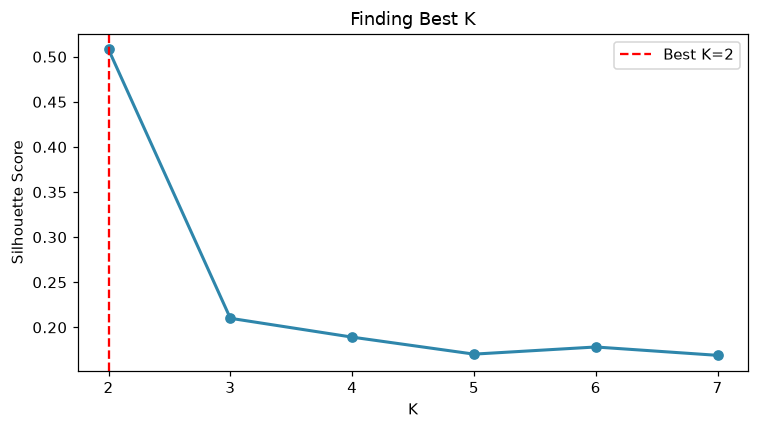

Best K = 2 with score = 0.508


In [71]:
# plotting silhouette scores
best_k = list(K_range)[int(np.argmax(sil_scores))]
plt.figure(figsize=(7, 4))
plt.plot(list(K_range), sil_scores, 'o-', color='#2E86AB', linewidth=2)
plt.axvline(best_k, color='red', linestyle='--', label=f'Best K={best_k}')
plt.xlabel('K'); plt.ylabel('Silhouette Score')
plt.title('Finding Best K'); plt.legend()
plt.tight_layout(); plt.show()
print(f"Best K = {best_k} with score = {max(sil_scores):.3f}")


> **Clustering Finding:** Silhouette analysis identifies $K = 2$ as the optimal cluster count (silhouette score = 0.508), revealing two well-differentiated structural operational clusters among the sampled farms.


In [72]:
# applying final kmeans
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels   = km_final.fit_predict(X_scaled)
df_cl    = X_cl.copy()
df_cl['Cluster'] = labels + 1
print("Cluster sizes:")
print(df_cl['Cluster'].value_counts().sort_index())


Cluster sizes:
Cluster
1     234
2    3766
Name: count, dtype: int64


In [73]:
# PCA to visualize clusters in 2D
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
ev    = pca.explained_variance_ratio_


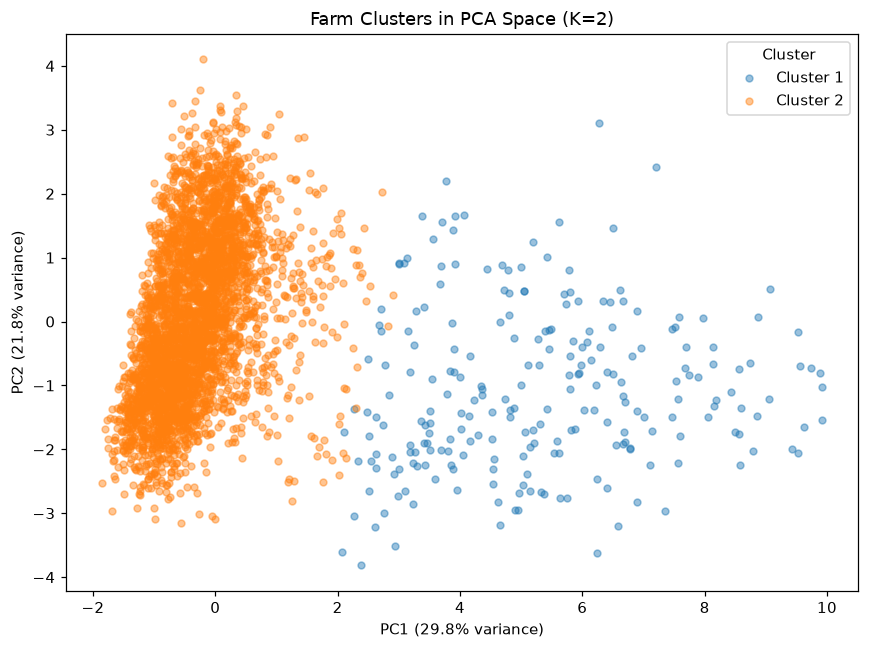

In [74]:
# scatter plot of farm clusters
fig, ax = plt.subplots(figsize=(8, 6))
colors_cl = sns.color_palette('tab10', best_k)
for k in range(best_k):
    mask = labels == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               alpha=0.45, s=20, color=colors_cl[k], label=f'Cluster {k+1}')
ax.set_xlabel(f'PC1 ({ev[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({ev[1]*100:.1f}% variance)')
ax.set_title(f'Farm Clusters in PCA Space (K={best_k})')
ax.legend(title='Cluster'); plt.tight_layout(); plt.show()


In [75]:
# cluster profile - what's special about each cluster
cluster_profile = df_cl.groupby('Cluster')[cluster_feats].mean().round(2)
cluster_profile['Count'] = df_cl['Cluster'].value_counts().sort_index()
cluster_profile


,Yield_Tonnes_Ha,Profit_per_Hectare_INR,Water_Efficiency_t_per_1000m3,NPK_Total_kg_ha,Disease_Pest_Risk_pct,Seed_Quality_Score,Rainfall_mm,Avg_Temperature_C,Count
Cluster,,,,,,,,,
1,55.35,127066.24,36.35,291.30,46.38,0.82,613.90,27.06,234
2,2.15,6502.02,3.46,282.26,46.37,0.83,599.96,26.80,3766


> **Cluster Insight:** Cluster 1 represents specialized commercial farms (e.g., intensive sugarcane) achieving high yields (55.4 T/Ha) and high profits (Rs. 1.27 Lakh/Ha), whereas Cluster 2 encompasses standard diversified smallholders with modest yields (2.15 T/Ha) and thin profit margins.


## 17. Final Summary

In [76]:
# consolidated seasonal performance summary
final = df.groupby('Season').agg(
    Total_Farms        = ('Farm_ID',                    'count'),
    Avg_Yield_T_Ha     = ('Yield_Tonnes_Ha',             'mean'),
    Avg_Profit_Rs      = ('Profit_INR',                  'mean'),
    Pct_Profitable     = ('Is_Profitable',  lambda x: round(x.mean()*100, 1)),
    Avg_Rainfall_mm    = ('Rainfall_mm',                 'mean'),
    Avg_Pest_Risk_pct  = ('Disease_Pest_Risk_pct',        'mean'),
    Avg_Water_m3       = ('Water_Used_m3',                'mean'),
).round(2)
final.loc[SEASON_ORDER]


,Total_Farms,Avg_Yield_T_Ha,Avg_Profit_Rs,Pct_Profitable,Avg_Rainfall_mm,Avg_Pest_Risk_pct,Avg_Water_m3
Season,,,,,,,
Kharif,1779,5.63,178914.65,57.80,852.33,54.47,6102.20
Rabi,1627,5.09,87689.47,48.90,435.90,40.48,5846.99
Zaid,594,4.63,-24804.82,35.50,298.95,38.22,6419.89


**Summary Insight:** Across all evaluated dimensions, Kharif functions as the primary driver of agrarian income (57.8% profitable, Rs. 1.79L avg profit), while Zaid represents a high-cost, high-loss season requiring targeted irrigation and crop insurance support.


## Conclusions

Based on the analysis:

1. **Kharif is the best season** for farming - highest yields, best profits, 58% of farms are profitable
2. **Zaid is very risky** - only 36% farms make profit, average is actually a loss
3. **Rainfall strongly drives pest risk** (r=0.63) - kharif has most disease pressure
4. **Crop mix doesn't change much across seasons** - farmers grow similar crops in all seasons
5. **Yield is highly predictable** - Random Forest got R2 of 0.96 which is great
6. **Two types of farms exist** - high input/high output vs low input farms

### Recommendations
- Zaid farmers should switch to drought-tolerant crops (maize, groundnut)
- Drip irrigation gives best water efficiency - should be promoted more
- Kharif farmers need pest management advisory before monsoon hits
- Government should provide crop insurance for Zaid season farmers
